<a href="https://www.kaggle.com/code/gimsujin/telco-customer-churn-prediction?scriptVersionId=306419075" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 문맥 (Context)
고객을 유지하기 위해 행동을 예측하세요. 모든 관련 고객 데이터를 분석하고 집중적인 고객 유지 프로그램을 개발할 수 있습니다. 

# 콘텐츠 (Content)
각 행(row)은 한 명의 고객을 나타내며, 각 열(column)에는 메타데이터 열에 설명된 고객의 속성이 포함되어 있습니다.

이 데이터 세트에는 다음에 대한 정보가 포함되어 있습니다:

- 지난달 내에 떠난 고객들 – 해당 열의 이름은 Churn(이탈)입니다. => Target

- 각 고객이 가입한 서비스들 – 전화, 다중 회선, 인터넷, 온라인 보안, 온라인 백업, 기기 보호, 기술 지원, 스트리밍 TV 및 영화

- 고객 계정 정보 – 고객 유지 기간(가입 기간), 계약 유형, 결제 방법, 종이 없는 청구서(전자 청구) 여부, 월별 요금 및 총 요금

- 고객에 대한 인구통계학적 정보 – 성별, 연령대, 파트너 및 부양가족 유무

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
rawdf = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 1. 데이터 확인

In [3]:
rawdf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- **customerID**
- **gender** : Whether the customer is a male or a female
  고객이 남성인지 여성인지
- **SeniorCitizen** : Whether the customer is a senior citizen or not (1, 0)
  고객이 노인인지 아닌지 여부(1, 0)
- **Partner** : Whether the customer has a partner or not (Yes, No)
  고객에게 파트너가 있는지 여부 (예, 아니오) -> 결혼 유무인가?
- **Dependents** : Whether the customer has dependents or not (Yes, No)
  고객에게 부양가족이 있는지 여부 (예, 아니오)
- **tenure** : Number of months the customer has stayed with the company
  고객이 해당 회사에 머문 기간(개월 수)
- **PhoneService** : Whether the customer has a phone service or not (Yes, No)
  고객이 전화 서비스를 이용하고 있는지 여부 (예, 아니오)
- **MultipleLines** : Whether the customer has multiple lines or not (Yes, No, No phone service)
  고객이 여러 회선을 사용하는지 여부 (예, 아니오, 전화 서비스 없음)
- **InternetService** : Customer’s internet service provider (DSL, Fiber optic, No)
  고객의 인터넷 서비스 제공업체(DSL, 광섬유, 기타)
- **OnlineSecurity** : Whether the customer has online security or not (Yes, No, No internet service)
  고객이 온라인 보안 서비스를 이용하고 있는지 여부 (예, 아니오, 인터넷 서비스 없음)
- **OnlineBackup** : Whether the customer has online backup or not (Yes, No, No internet service)
  고객이 온라인 백업 서비스를 이용하는지 여부 (인터넷 서비스 이용, 이용 안 함, 이용 안 함)
- **DeviceProtection** : Whether the customer has device protection or not (Yes, No, No internet service)
  고객이 기기 보호 서비스를 이용하고 있는지 여부 (예, 아니오, 인터넷 서비스 없음)
- **TechSupport** : Whether the customer has tech support or not (Yes, No, No internet service)
  고객이 기술 지원을 받는지 여부 (예, 아니오, 인터넷 서비스 없음)
- **StreamingTV** : Whether the customer has streaming TV or not (Yes, No, No internet service)
  고객이 스트리밍 TV를 이용하는지 여부 (인터넷 서비스 이용, 이용 안 함, 이용 안 함)
- **StreamingMovies** : Whether the customer has streaming movies or not (Yes, No, No internet service)
  고객이 스트리밍 영화 서비스를 이용하는지 여부 (예, 아니오, 인터넷 서비스 없음)
- **Contract** : The contract term of the customer (Month-to-month, One year, Two year)
  고객의 계약 기간 (월 단위, 1년, 2년)
- **PaperlessBilling** : Whether the customer has paperless billing or not (Yes, No)
  고객이 종이 없는 청구서를 사용하는지 여부 (예, 아니오)
- **PaymentMethod** : The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
  고객의 결제 방식 (전자수표, 우편수표, 은행 송금(자동), 신용카드(자동))
- **MonthlyCharges** : The amount charged to the customer monthly
  고객에게 매달 청구되는 금액
- **TotalCharges** : The total amount charged to the customer
  고객에게 청구된 총 금액
- **Churn** : Whether the customer churned or not (Yes or No)
  고객 이탈 여부 (예 또는 아니오)

In [4]:
rawdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


결측치가 존재하지 않는다. 

- 학습에 필요없는 custom id 를 삭제해준다. 

또 데이터 타입을 보니, 타입 변환이 필요해보인다. 

- seniorcitizen 은 0과 1로 이루어져 수치형으로 되어있으나, 범주형으로 처리하는 것이 적절하다
- totalCharges 는 요금인데 범주형으로 되어 있다. 

In [5]:
df1 = rawdf.drop('customerID', axis=1)

In [6]:
df1

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [7]:
df1['TotalCharges'].isnull().sum()

np.int64(0)

In [8]:
df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'], errors='coerce')
df1['TotalCharges'].isnull().sum()

np.int64(11)

결측치가 존재하지 않다가, 숫자로 변환을 시도하니 결측치가 발생했다. 

숫자로 변환할 수 없는 무언가가 들어있던 모양이다. 

결측치는 나중에 '학습 데이터의 중앙값' 등으로 채우기 위해 일단 두기


In [9]:
df1['SeniorCitizen'] = df1['SeniorCitizen'].astype('category')

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

# 2. 데이터 분리

In [11]:
from sklearn.model_selection import train_test_split

# 1. 특성(X)과 타겟(y) 분리
X = df1.drop('Churn', axis=1)
y = df1['Churn']

# 2. 데이터 분할 (8:2 비율)
# random_state=42: 결과 재현을 위해 설정
# stratify=y: 타겟(Churn)의 비율을 학습/테스트 세트에 동일하게 분배
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"전체 데이터 수: {len(df1)}")
print(f"학습 데이터 수: {len(X_train)}")
print(f"테스트 데이터 수: {len(X_test)}")

# 비율 확인 (잘 나뉘었는지!)
print("\n--- 타겟 비율 확인 ---")
print(f"원본 비율:\n{y.value_counts(normalize=True)}")
print(f"학습 세트 비율:\n{y_train.value_counts(normalize=True)}")

전체 데이터 수: 7043
학습 데이터 수: 5634
테스트 데이터 수: 1409

--- 타겟 비율 확인 ---
원본 비율:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
학습 세트 비율:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64


# 3. EDA, 단변량 분석
변수 하나하나가 어떻게 생겼나?
- 타겟 데이터, 수치형/범주형 데이터의 분포를 확인한다.
- 타겟과 변수간 관계를 확인한다.
- 변수간 상관관계 확인한다. 

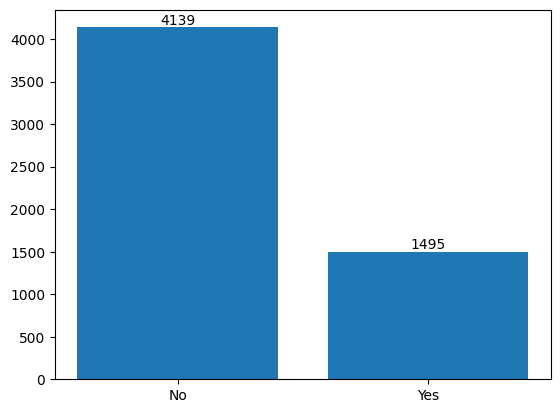

In [12]:
'''타겟 데이터 분포 확인'''
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 준비
val_count = y_train.value_counts().sort_index()

# 그래프 생성을 위한 figure와 axes 객체 초기화
fig, ax = plt.subplots()

# 막대 그래프 생성
ax.bar(val_count.index, val_count.values)

# 각 막대에 숫자 추가
for i, count in enumerate(val_count.values):
    ax.text(i, count + 0.1, str(count), ha='center', va='bottom')

plt.show()

train의 타겟(churn) 분포를 확인해보니 No가 압도적으로 많다. 

바로 데이터 불균형이다. 

불균형 문제 해결을 위해 모델링 단계에서 SMOTE 기법를 사용하겠다. 



In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            5634 non-null   object  
 1   SeniorCitizen     5634 non-null   category
 2   Partner           5634 non-null   object  
 3   Dependents        5634 non-null   object  
 4   tenure            5634 non-null   int64   
 5   PhoneService      5634 non-null   object  
 6   MultipleLines     5634 non-null   object  
 7   InternetService   5634 non-null   object  
 8   OnlineSecurity    5634 non-null   object  
 9   OnlineBackup      5634 non-null   object  
 10  DeviceProtection  5634 non-null   object  
 11  TechSupport       5634 non-null   object  
 12  StreamingTV       5634 non-null   object  
 13  StreamingMovies   5634 non-null   object  
 14  Contract          5634 non-null   object  
 15  PaperlessBilling  5634 non-null   object  
 16  PaymentMethod     5634 non

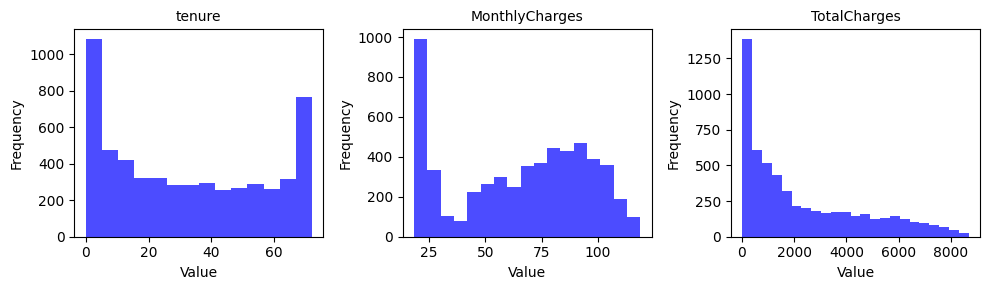

In [14]:
'''수치형 데이터 분포 확인'''
numeric_train = X_train[['tenure','MonthlyCharges','TotalCharges']]


# 플롯 초기화 (1x3 그리드, figsize 설정)
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

# 히스토그램 그리기
for ax, column in zip(axs.flatten(), numeric_train.columns):
    ax.hist(numeric_train[column], bins='auto', alpha=0.7, color='blue')
    ax.set_title(column, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# 빈 Axes 숨기기 (만약 컬럼 수가 subplot 수보다 적을 경우)
for i in range(len(numeric_train.columns), 3):  # 3는 subplot의 총 개수 (1x3)
    fig.axes[i].axis('off')
    

plt.tight_layout()

plt.show()

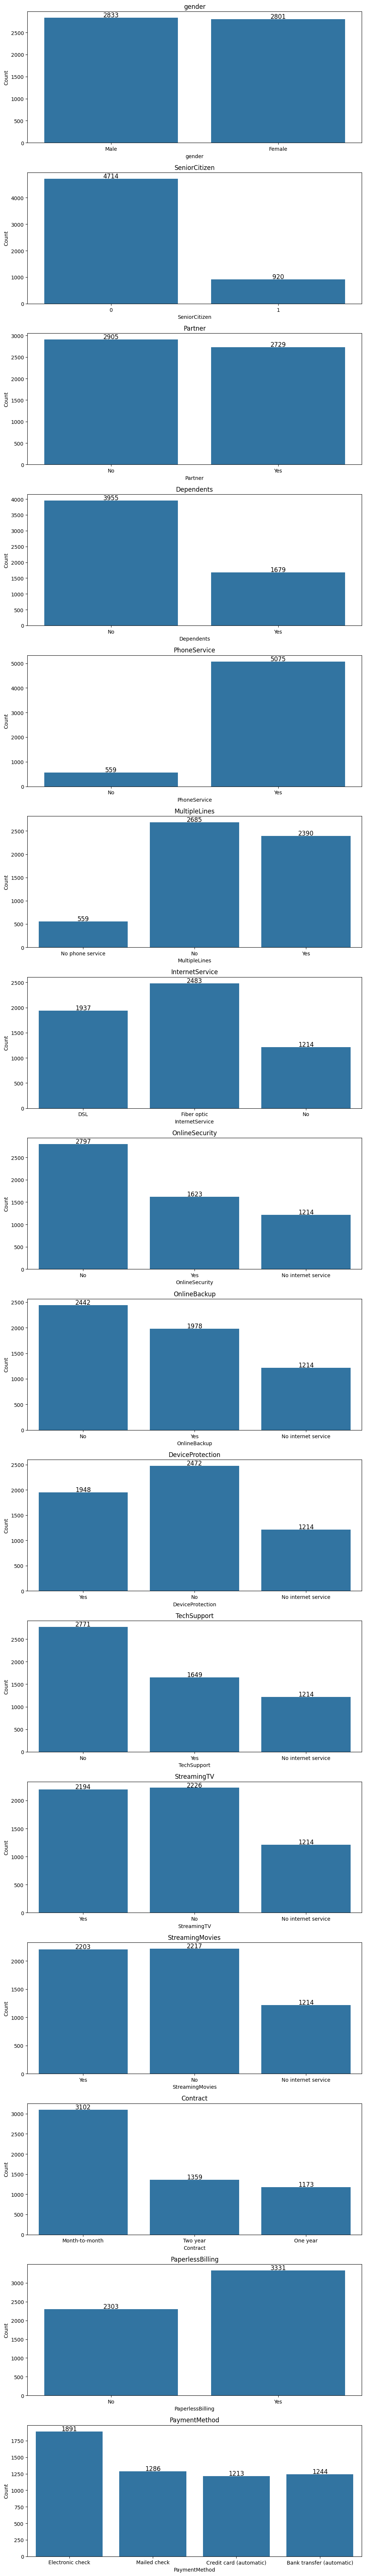

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 프레임과 범주형 컬럼 이름을 정의합니다.
dframe = X_train  
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                   'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaperlessBilling', 'PaymentMethod']

# 3x1 그리드 설정
fig, axs = plt.subplots(16, 1, figsize=(10, 70))

# 각 범주형 변수에 대해 반복하여 카운트 플롯 생성
for i, col in enumerate(categorical_cols):
    ax = sns.countplot(x=col, data=dframe, ax=axs[i])
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    
    # 각 막대에 숫자 추가
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, color='black', 
                    xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()  

# 4. EDA, 이변량 분석
각 변수가 Target이랑 어떤 관계가 있는가 ->

타겟이 No일때와 Yes일때 각각의 데이터를 만들어서 히스토그램(Historgram)과 을 박스플롯(Botplot)을 만들기

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

df4 = df1.copy()

def draw_multiple_charts(df, columns, sample_size=1495):
    # 1. 출력할 전체 칸(Grid) 계산 (가로 2개씩 배치 예시)
    n_cols = 2  # 한 줄에 2개 컬럼씩 표시 (각 컬럼당 히스토그램+박스플롯 세트)
    n_rows = len(columns)
    
    # 전체 도화지 크기 설정 (컬럼 수에 따라 높이 조절)
    fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
    
    # 컬럼이 1개일 경우 axes가 2차원이 아니게 되는 현상 방지
    if n_rows == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        # 데이터 분리 및 샘플링 (에러 방지를 위해 실제 개수와 비교)
        churn_no = df[df['Churn'] == 'No'][col]
        churn_yes = df[df['Churn'] == 'Yes'][col]
        
        # 샘플링 (데이터가 부족할 경우를 대비해 min 사용)
        dframe0 = churn_no.sample(min(len(churn_no), sample_size), random_state=42)
        dframe1 = churn_yes # Yes는 있는 그대로 사용
        
        # x축 범위 설정
        xmin = min(dframe0.min(), dframe1.min())
        xmax = max(dframe0.max(), dframe1.max())

        # 왼쪽: 히스토그램
        ax_hist = axes[i][0]
        ax_hist.hist(dframe0, alpha=0.5, color='blue', edgecolor='black', label='Churn: No', range=(xmin, xmax))
        ax_hist.hist(dframe1, alpha=0.5, color='red', edgecolor='black', label='Churn: Yes', range=(xmin, xmax))
        ax_hist.set_title(f'Histogram of {col}')
        ax_hist.legend()

        # 오른쪽: 박스플롯
        ax_box = axes[i][1]
        sns.boxplot(x='Churn', y=col, data=df, ax=ax_box, palette={'No': 'blue', 'Yes': 'red'})
        ax_box.set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [17]:
df4.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


/tmp/ipykernel_17/2585163364.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax_box, palette={'No': 'blue', 'Yes': 'red'})
/tmp/ipykernel_17/2585163364.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax_box, palette={'No': 'blue', 'Yes': 'red'})
/tmp/ipykernel_17/2585163364.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=ax_box, palette={'No': 'blue', 'Yes': 'red'})


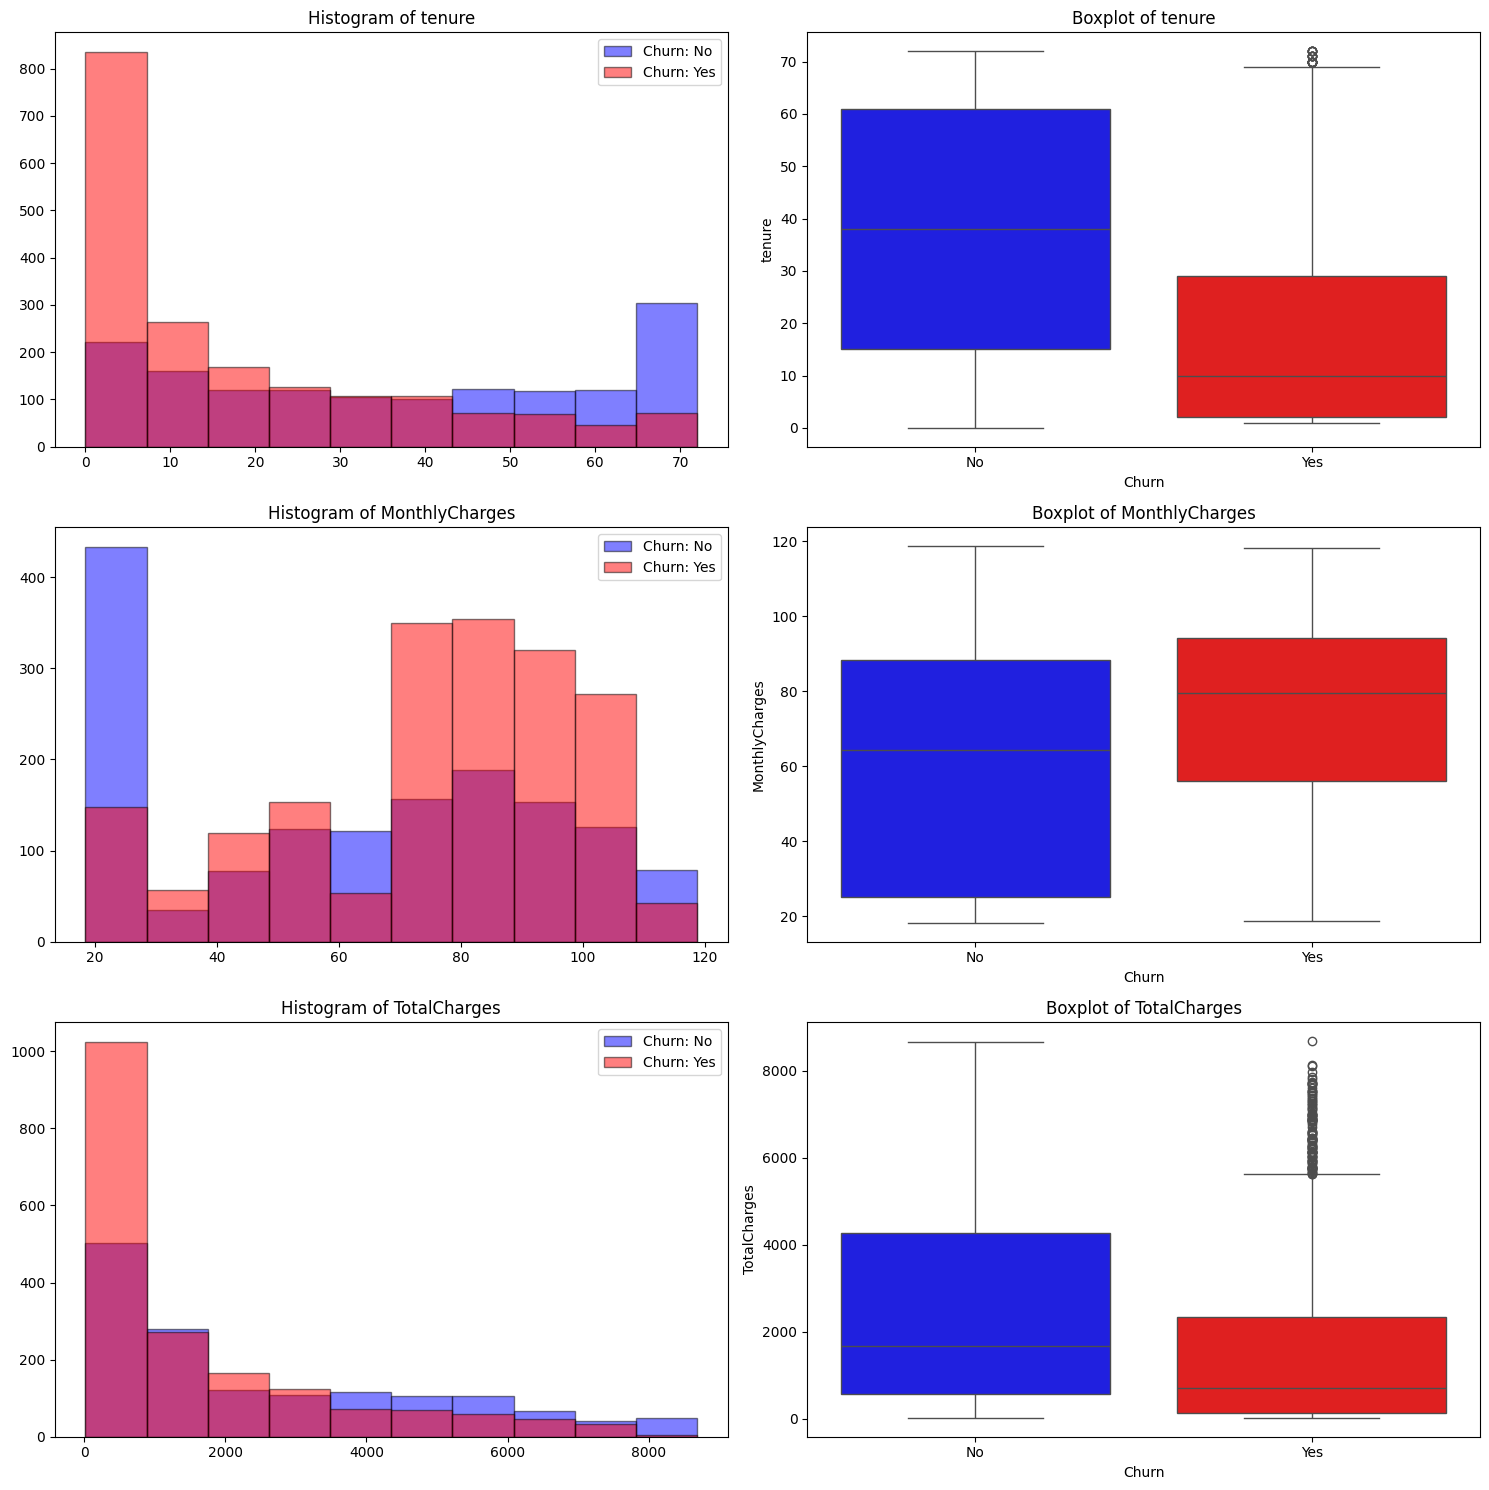

In [18]:
'''타겟과 수치형의 관계'''
columns = [
    'tenure','MonthlyCharges','TotalCharges'
]

draw_multiple_charts(df4, columns)

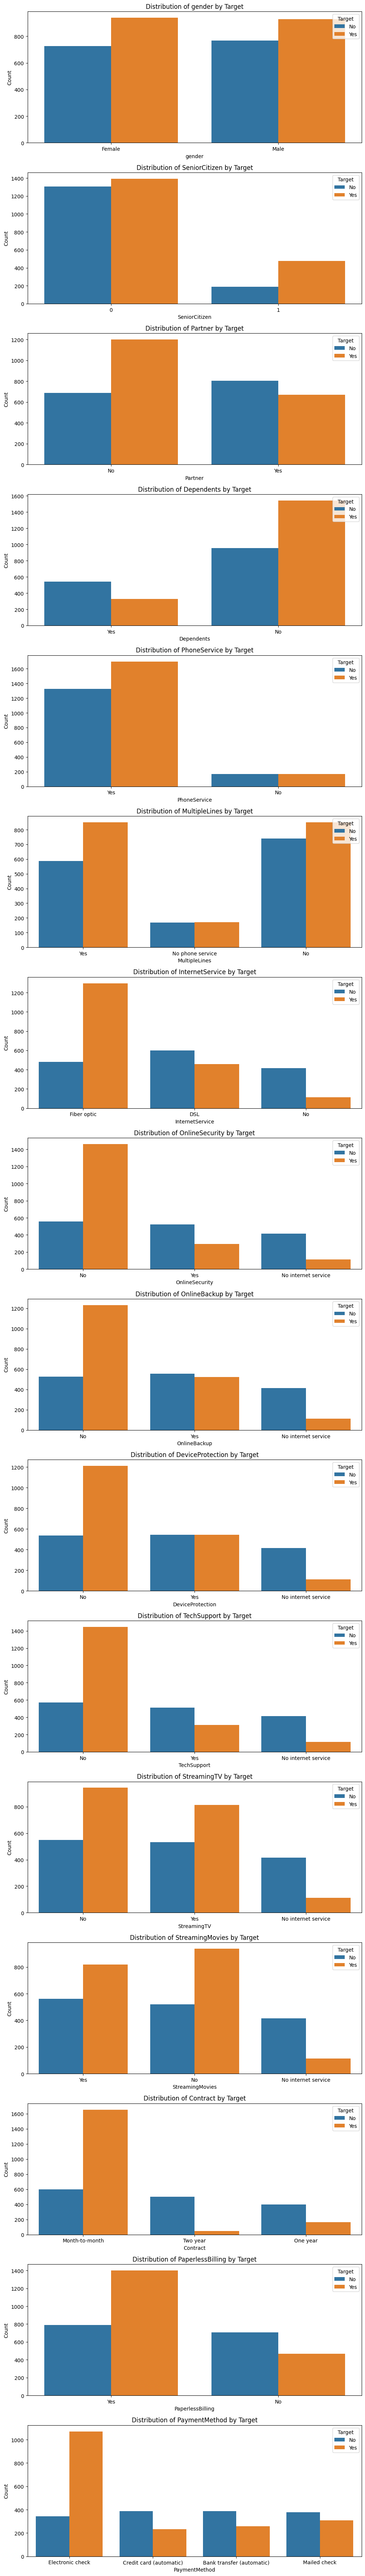

In [19]:
'''타겟과 범주형의 관계'''
# 필요한 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 타겟 기준으로 데이터 분리 및 샘플링
train_dframe0 = df4[df4['Churn'] == 'No'].sample(1495)
train_dframe1 = df4[df4['Churn'] == 'Yes']

# 데이터 다시 합치기
train_dframe = pd.concat([train_dframe0, train_dframe1])

# 3x1 서브플롯 생성
fig_cat, axs = plt.subplots(16, 1, figsize=(10, 70))

# 서브플롯에 카운트 플롯 그리기
categorical_cols = [
                   'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                   'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for i, categorical_col in enumerate(categorical_cols):
    sns.countplot(x=categorical_col, hue='Churn', data=train_dframe, ax=axs[i])
    axs[i].set_title(f'Distribution of {categorical_col} by Target')
    axs[i].set_xlabel(categorical_col)
    axs[i].set_ylabel('Count')
    axs[i].legend(title='Target', loc='upper right')

plt.tight_layout()
plt.show()

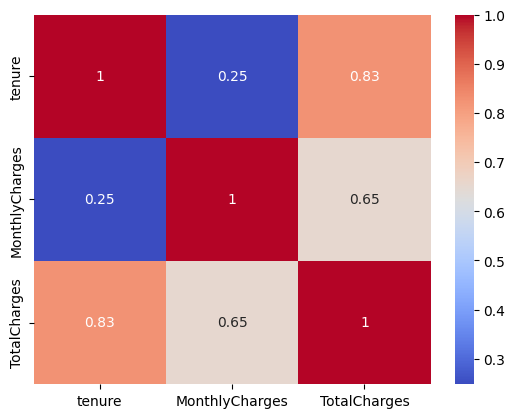

In [20]:
'''수치형 변수 상관관계 (다중공선성 확인)'''
corr = df4[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

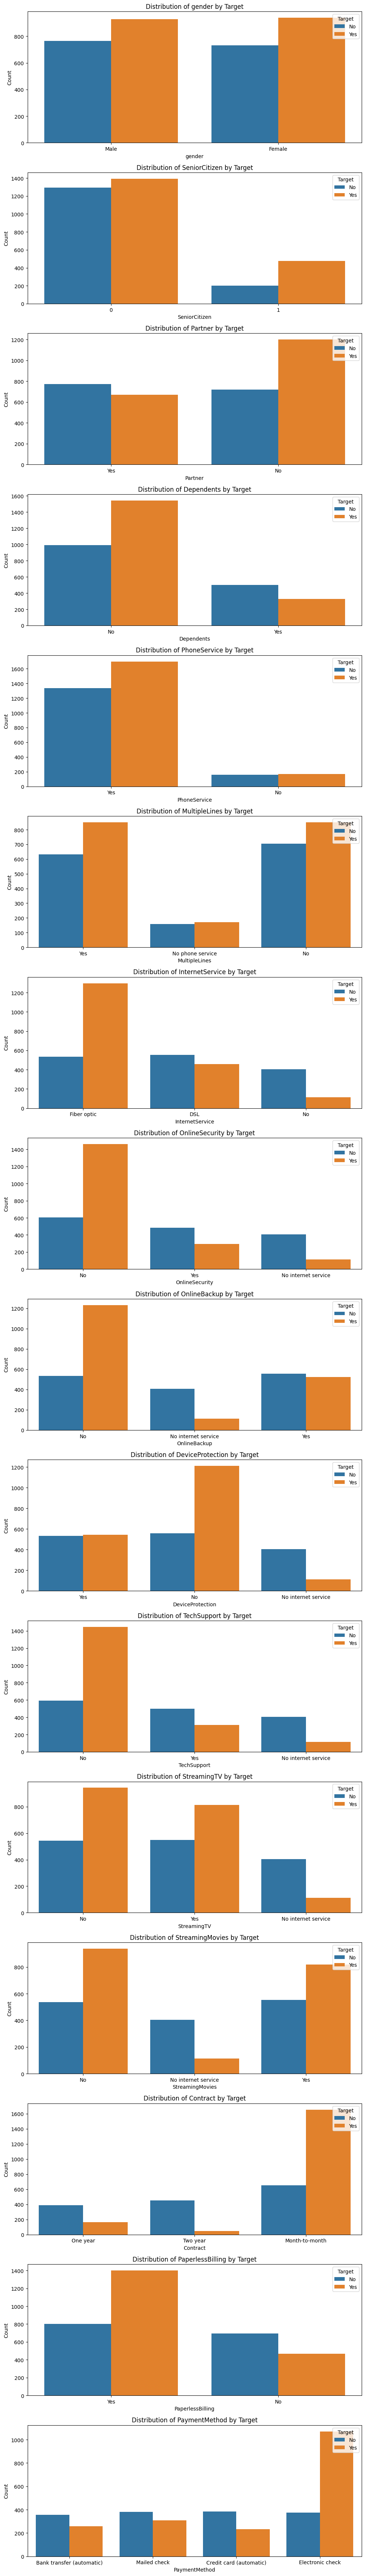

In [21]:
'''타겟과 범주형의 관계'''
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

train_dframe0 = df4[df4['Churn'] == 'No'].sample(1495)
train_dframe1 = df4[df4['Churn'] == 'Yes']

train_dframe = pd.concat([train_dframe0, train_dframe1])

fig_cat, axs = plt.subplots(16, 1, figsize=(10,70))

categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for i, categorical_col in enumerate(categorical_cols):
    sns.countplot(x=categorical_col, hue='Churn', data=train_dframe, ax=axs[i])
    axs[i].set_title(f'Distribution of {categorical_col} by Target')
    axs[i].set_xlabel(categorical_col)
    axs[i].set_ylabel('Count')
    axs[i].legend(title='Target', loc='upper right')

plt.tight_layout()
plt.show()

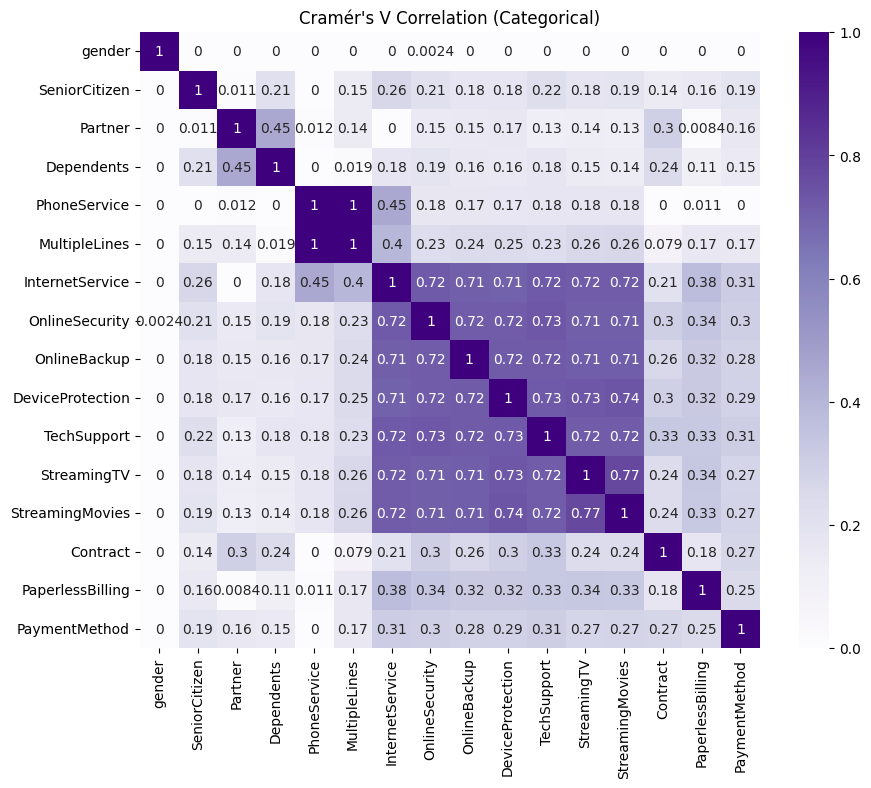

In [22]:
'''
범주형 상관관계 확인
'''
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    """ 두 범주형 변수 간의 크래머 V 지수를 계산하는 함수 """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 분석하고 싶은 범주형 컬럼들 리스트
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
rows = []

for var1 in cat_cols:
    col = []
    for var2 in cat_cols:
        col.append(cramers_v(df4[var1], df4[var2]))
    rows.append(col)

v_results = pd.DataFrame(rows, columns=cat_cols, index=cat_cols)

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(v_results, annot=True, cmap='Purples')
plt.title("Cramér's V Correlation (Categorical)")
plt.show()

# 5. EDA, 다변량 분석
여러 개의 변수가 동시에 작용할 때 어떤 시너지가 발생하는가 확인

1. 다중공선성 최종 점검(vif 계산)
2. 변수간 상호작용 탐색 -> 상관계수가 높았던 변수 위주로(point plot)
3. 클러스터링 가능성 확인 -> 성격이 같거나 다른 집단 확인 (pair plot)

In [23]:
'''다중공선성 확인 (vif)'''
df5 = df4.copy()

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. 결측치 처리된 수치형 데이터만 선택(결측치는 0으로)
vif_data = df5[['tenure', 'MonthlyCharges', 'TotalCharges']].fillna(0)

# 2. vif
vif_df = pd.DataFrame()
vif_df['feature'] = vif_data.columns
vif_df['VIF'] = [variance_inflation_factor(vif_data.values, 1) for i in range(len(vif_data.columns))]

print(vif_df)


          feature      VIF
0          tenure  3.35566
1  MonthlyCharges  3.35566
2    TotalCharges  3.35566


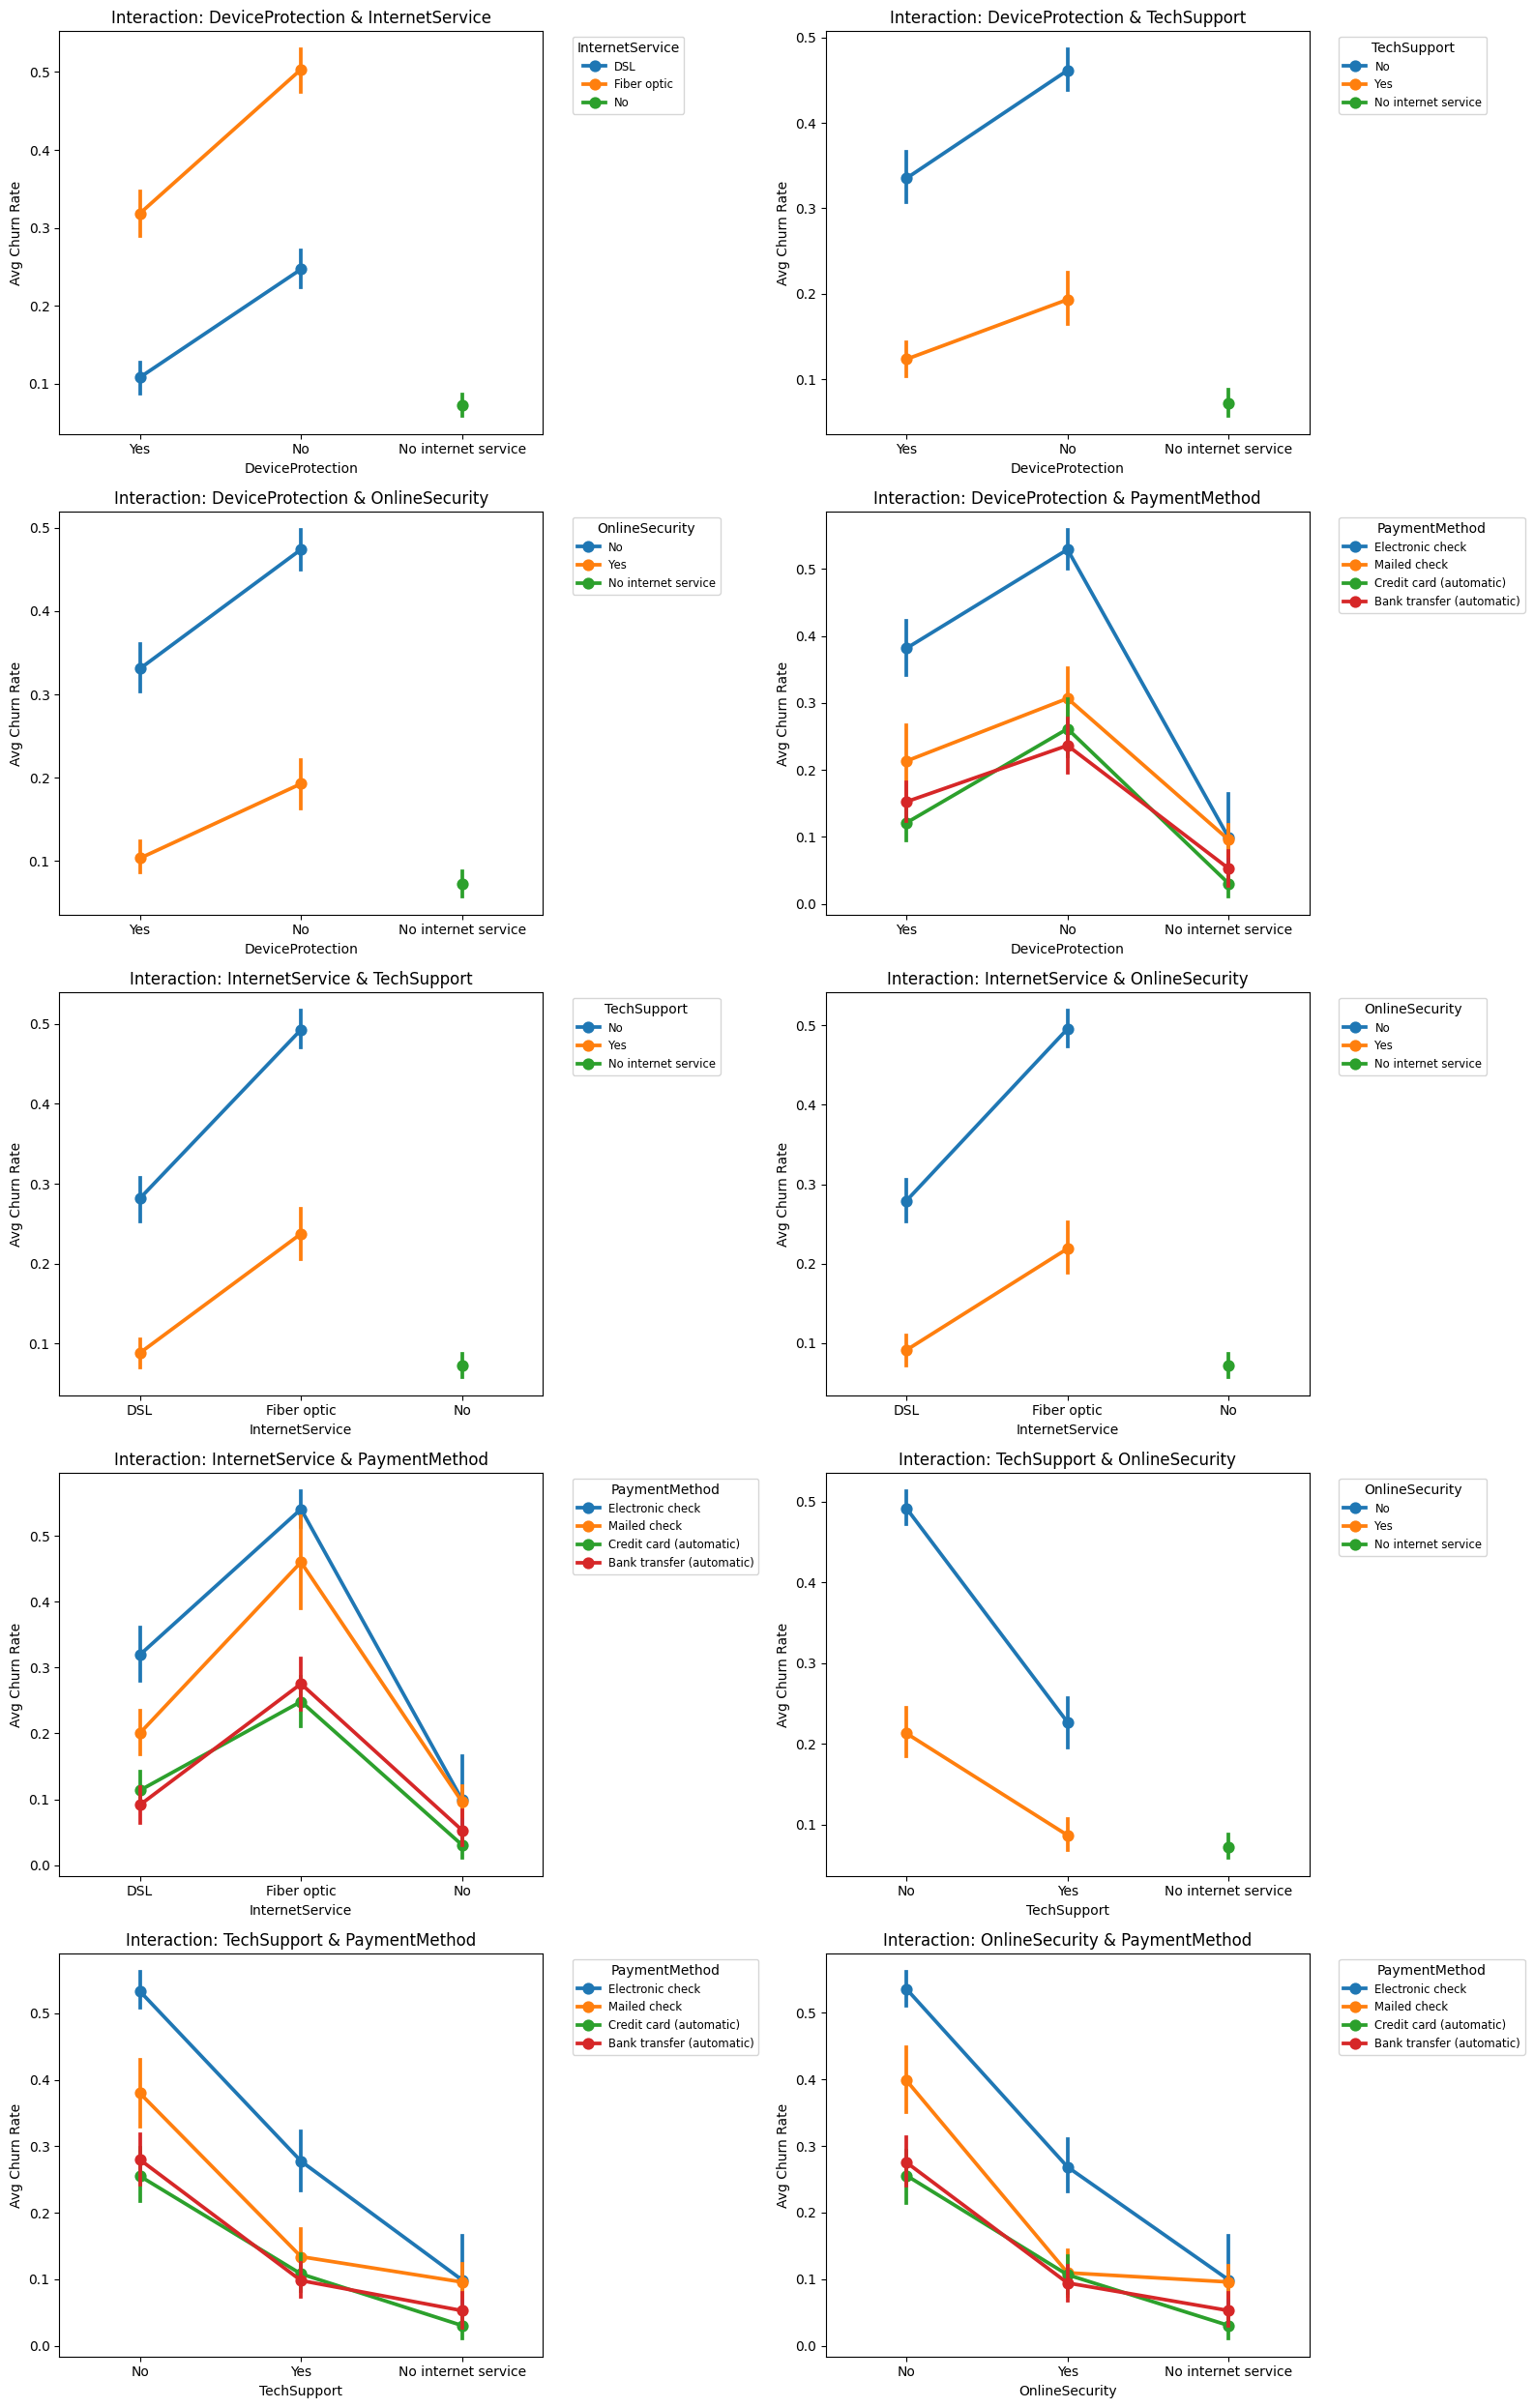

In [24]:
'''상호작용 (point plot)'''
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

# 1. 시각화용 데이터 준비 (X_train과 y_train 결합)
train_plot = X_train.copy()
train_plot['Churn_Num'] = y_train.map({'Yes': 1, 'No': 0})

# 2. 상호작용을 확인하고 싶은 '주요' 범주형 컬럼 리스트
# 이탈률 차이가 컸던 핵심 변수 위주로 
target_cols = ['DeviceProtection', 'InternetService', 'TechSupport', 'OnlineSecurity', 'PaymentMethod']

# 3. 모든 가능한 2개 조합(Pair) 생성
combos = list(combinations(target_cols, 2))

# 4. 반복문을 통한 자동 시각화
# subplot을 쓰면 한눈에 보기 편합니다. (예: 2열로 배치)
n_rows = (len(combos) + 1) // 2
fig, axs = plt.subplots(n_rows, 2, figsize=(16, n_rows * 5))
axs = axs.flatten()

for i, (col1, col2) in enumerate(combos):
    # 각 조합에 대해 pointplot 생성
    sns.pointplot(data=train_plot, x=col1, y='Churn_Num', hue=col2, ax=axs[i])
    axs[i].set_title(f'Interaction: {col1} & {col2}', fontsize=12)
    axs[i].set_ylabel('Avg Churn Rate')
    axs[i].legend(title=col2, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# 사용하지 않는 빈 서브플롯 숨기기
for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

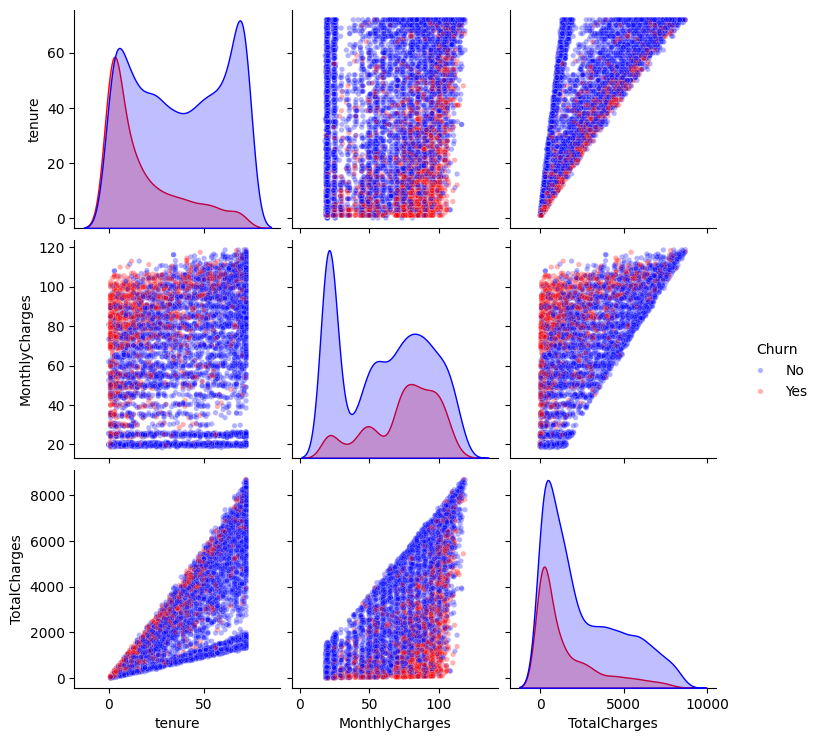

In [25]:
'''클러스터링 (pair plot)'''
col = ['tenure', 'MonthlyCharges', 'TotalCharges']

sns.pairplot(df5, vars=col, hue='Churn', palette=['blue','red'], plot_kws={'alpha':0.3, 's':15})
plt.show()